<a href="https://colab.research.google.com/github/jaronkawam/Echocardiogram-Acquisition-Guidance-System/blob/main/a4c_quality_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 63.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import os
drive.mount('/content/drive')

import pydicom


Mounted at /content/drive


In [ ]:
parent_dir = f'/content/drive/MyDrive/BME 499L: Senior Design iCardio/A4C iCardio' #/frames'


In [ ]:
metadata = pd.read_csv(parent_dir + '/a4c_dbd735cc-a38f-4baa-bbad-38934f49bd7f_quality_only.csv')
print(metadata)

              dicom_uuid   quality view  view_confidence  n_frames  height  \
0      di-50AC-CCA8-7214  0.195725  A4C         1.000000        27     708   
1      di-5BED-D33C-C66F  0.010198  A4C         0.576923        26     708   
2      di-81B5-7B63-00C7  0.983742  A4C         1.000000        28     708   
3      di-CA44-DE97-88DA  0.882458  A4C         0.960000        25     650   
4      di-A4B6-747F-4188  0.580956  A4C         1.000000        34     708   
...                  ...       ...  ...              ...       ...     ...   
47107  di-68C7-850D-549A  0.846678  A4C         1.000000        45     480   
47108  di-75CC-5BBA-0377  0.012340  A4C         1.000000        23     422   
47109  di-27F6-ED2F-BDF7  0.155895  A4C         0.916667        24     422   
47110  di-777E-06F3-114B  0.331215  A4C         1.000000        21     422   
47111  di-CEB8-5FA7-92F7  0.130000  A4C         1.000000        23     422   

       width        dx        dy              study            

In [ ]:
print(metadata[metadata['dicom_uuid'].str.contains('50AC')]['dicom_uuid'])

0        di-50AC-CCA8-7214
2121     di-39BC-50AC-A92E
22981    di-C667-50AC-2872
Name: dicom_uuid, dtype: object


In [ ]:
# generate paths (not all will actually exist)
def generate_png_path_fast(dicom_uuid):
    uuid_prefix1 = dicom_uuid[3:5]
    uuid_prefix2 = dicom_uuid[5:7]
    return f"{parent_dir}/frames/{uuid_prefix1}/{uuid_prefix2}/{dicom_uuid}_0.png"

metadata['png_path'] = metadata['dicom_uuid'].apply(generate_png_path_fast)
print(metadata[['dicom_uuid', 'png_path']].sample(5))

              dicom_uuid                                           png_path
26968  di-B608-23DA-1DC6  /content/drive/MyDrive/BME 499L: Senior Design...
30475  di-4736-797A-5EAA  /content/drive/MyDrive/BME 499L: Senior Design...
946    di-0BB5-5EA7-B7E9  /content/drive/MyDrive/BME 499L: Senior Design...
27654  di-6E40-D7AE-CF16  /content/drive/MyDrive/BME 499L: Senior Design...
2454   di-D995-1F14-EFD5  /content/drive/MyDrive/BME 499L: Senior Design...


In [ ]:
# check which paths dont exist, save existing paths to valid_data

import glob

# 1. Read ALL file paths into a set ONCE.
# This prevents 47,000 separate network calls to Google Drive.
print("Indexing files on Drive... this may take 1-2 minutes...")

# recursive=True ensures we look inside all the subfolders (uuid_prefix1/uuid_prefix2)
existing_files = set(glob.glob(f"{parent_dir}/frames/**/*.png", recursive=True))

print(f"Index complete. Found {len(existing_files)} files.")

# 2. Check existence instantly by looking up in the set
# This operation is effectively instant because it's just checking memory.
metadata['exists'] = metadata['png_path'].isin(existing_files)

# 3. (Optional) Filter your dataframe to keep only valid files
valid_metadata = metadata[metadata['exists']].copy()

print(f"Valid images: {len(valid_metadata)}")
print(f"Missing images: {len(metadata) - len(valid_metadata)}")

# Show a sample of missing files if any
if len(metadata) - len(valid_metadata) > 0:
    print("\nSample of missing files:")
    print(metadata[~metadata['exists']]['png_path'].head())

Indexing files on Drive... this may take 1-2 minutes...
Index complete. Found 640280 files.
Valid images: 14962
Missing images: 32150

Sample of missing files:
82     /content/drive/MyDrive/BME 499L: Senior Design...
85     /content/drive/MyDrive/BME 499L: Senior Design...
86     /content/drive/MyDrive/BME 499L: Senior Design...
140    /content/drive/MyDrive/BME 499L: Senior Design...
382    /content/drive/MyDrive/BME 499L: Senior Design...
Name: png_path, dtype: object


In [ ]:
# 1. Filter for high-quality images that actually exist
high_quality_df = valid_metadata[valid_metadata['quality'] > 0.999].copy()

# 2. Generate the relative path by removing the parent_dir prefix
high_quality_df['relative_path'] = high_quality_df['png_path'].str.replace(parent_dir + '/', '', regex=False)

# 3. Print the quality score alongside the relative path
print(f"Found {len(high_quality_df)} high-quality DICOMs (> 0.9)\n")
print(high_quality_df[['quality', 'relative_path']].to_string(index=False))

Found 1635 high-quality DICOMs (> 0.9)

 quality                        relative_path
0.999284 frames/45/C9/di-45C9-C06D-3602_0.png
0.999393 frames/65/2A/di-652A-C9B2-6EB0_0.png
0.999940 frames/78/26/di-7826-B9BC-A1D0_0.png
0.999787 frames/05/E3/di-05E3-8602-AD91_0.png
0.999759 frames/23/11/di-2311-6434-421E_0.png
0.999627 frames/EC/DB/di-ECDB-DD3F-01C7_0.png
0.999823 frames/22/BB/di-22BB-D14A-934A_0.png
0.999607 frames/85/52/di-8552-3A45-D42C_0.png
0.999976 frames/D8/1A/di-D81A-FEDE-D17E_0.png
0.999574 frames/50/8D/di-508D-3820-A8AA_0.png
0.999829 frames/1B/67/di-1B67-9E56-B7D5_0.png
0.999229 frames/0C/0E/di-0C0E-F2E4-64B7_0.png
0.999152 frames/C0/83/di-C083-51D6-833D_0.png
0.999929 frames/D9/21/di-D921-5E21-7A59_0.png
0.999047 frames/E7/96/di-E796-BBDB-5729_0.png
0.999902 frames/2B/8F/di-2B8F-BAA5-E85A_0.png
0.999991 frames/69/D9/di-69D9-9831-292D_0.png
0.999878 frames/9E/FB/di-9EFB-1A78-94D9_0.png
0.999547 frames/6F/86/di-6F86-09FD-C307_0.png
0.999595 frames/20/9C/di-209C-1BDD-5ABC_

In [ ]:
# Define the output path for the CSV
csv_output_path = parent_dir + '/high_quality_metadata.csv'

# Save the dataframe
# index=False prevents an extra column of row numbers from being added
high_quality_df.to_csv(csv_output_path, index=False)

print(f"Dataframe saved successfully to: {csv_output_path}")

Dataframe saved successfully to: /content/drive/MyDrive/BME 499L: Senior Design iCardio/A4C iCardio/high_quality_metadata.csv


In [ ]:
# 1. Filter for images with quality scores between 0.7 and 0.8
mid_quality_df = valid_metadata[(valid_metadata['quality'] >= 0.7) & (valid_metadata['quality'] <= 0.8)].copy()

# 2. Generate the relative path by removing the parent_dir prefix
mid_quality_df['relative_path'] = mid_quality_df['png_path'].str.replace(parent_dir + '/', '', regex=False)

# 3. Print the quality score alongside the relative path
print(f"Found {len(mid_quality_df)} DICOMs with quality between 0.7 and 0.8\n")
print(mid_quality_df[['quality', 'relative_path']].to_string(index=False))

Found 922 DICOMs with quality between 0.7 and 0.8

 quality                        relative_path
0.781098 frames/60/8A/di-608A-31AA-829E_0.png
0.748180 frames/5F/A9/di-5FA9-4085-C08F_0.png
0.762912 frames/68/CE/di-68CE-0FE1-CEE7_0.png
0.768564 frames/75/F3/di-75F3-6557-19D7_0.png
0.704542 frames/EC/7B/di-EC7B-72B7-CFC3_0.png
0.739910 frames/C1/86/di-C186-2912-9D6D_0.png
0.709248 frames/51/3E/di-513E-6FFD-233B_0.png
0.799428 frames/4C/04/di-4C04-2D7D-0FDB_0.png
0.707826 frames/E1/4D/di-E14D-8A18-1E40_0.png
0.776255 frames/AF/6C/di-AF6C-4E5A-66F0_0.png
0.722366 frames/01/35/di-0135-3658-F839_0.png
0.774245 frames/0F/C4/di-0FC4-78CB-1F75_0.png
0.735815 frames/AE/1B/di-AE1B-AF0A-B98B_0.png
0.709711 frames/A5/D0/di-A5D0-6104-68D7_0.png
0.727017 frames/1A/59/di-1A59-E8DA-CB6A_0.png
0.760395 frames/C8/BC/di-C8BC-C898-E68F_0.png
0.757789 frames/26/F0/di-26F0-135B-2CE8_0.png
0.735007 frames/EC/42/di-EC42-0F52-FEB4_0.png
0.736987 frames/05/39/di-0539-341F-34A3_0.png
0.792799 frames/BB/C3/di-BBC3

In [ ]:
# Define the output path for the CSV
csv_output_path = parent_dir + '/mid_quality_metadata.csv'

# Save the dataframe
# index=False prevents an extra column of row numbers from being added
mid_quality_df.to_csv(csv_output_path, index=False)

print(f"Dataframe saved successfully to: {csv_output_path}")

Dataframe saved successfully to: /content/drive/MyDrive/BME 499L: Senior Design iCardio/A4C iCardio/mid_quality_metadata.csv


In [ ]:
# 1. Filter for images with quality scores between 0.4 and 0.5
mid_low_quality_df = valid_metadata[(valid_metadata['quality'] >= 0.4) & (valid_metadata['quality'] <= 0.5)].copy()

# 2. Generate the relative path by removing the parent_dir prefix
mid_low_quality_df['relative_path'] = mid_low_quality_df['png_path'].str.replace(parent_dir + '/', '', regex=False)

# 3. Print the quality score alongside the relative path
print(f"Found {len(mid_low_quality_df)} DICOMs with quality between 0.4 and 0.5\n")
print(mid_low_quality_df[['quality', 'relative_path']].to_string(index=False))

Found 623 DICOMs with quality between 0.4 and 0.5

 quality                        relative_path
0.493646 frames/2A/F4/di-2AF4-25EA-ABF9_0.png
0.463404 frames/36/2D/di-362D-7DA3-540A_0.png
0.405738 frames/77/70/di-7770-D782-7822_0.png
0.451508 frames/17/F7/di-17F7-75B8-054A_0.png
0.494565 frames/98/EF/di-98EF-E812-0F2B_0.png
0.425789 frames/64/7B/di-647B-E97D-915F_0.png
0.471320 frames/F1/F8/di-F1F8-4874-CFE8_0.png
0.475708 frames/0F/92/di-0F92-9289-796D_0.png
0.484327 frames/7A/9B/di-7A9B-B713-1224_0.png
0.466251 frames/C9/7B/di-C97B-1670-E4DB_0.png
0.466736 frames/34/A8/di-34A8-159F-F1CA_0.png
0.440982 frames/D1/37/di-D137-2281-3148_0.png
0.479012 frames/DB/34/di-DB34-0030-DDD4_0.png
0.451458 frames/0D/3E/di-0D3E-5DAA-4B08_0.png
0.459335 frames/40/AC/di-40AC-E2FB-E547_0.png
0.486110 frames/A4/6A/di-A46A-4429-2BAE_0.png
0.436859 frames/24/BB/di-24BB-D40C-9CC0_0.png
0.483214 frames/FC/F1/di-FCF1-D4E6-0C2B_0.png
0.431766 frames/D9/E9/di-D9E9-0582-6E06_0.png
0.447112 frames/BE/9C/di-BE9C

In [ ]:
# Define the output path for the CSV
csv_output_path = parent_dir + '/mid_low_quality_metadata.csv'

# Save the dataframe
# index=False prevents an extra column of row numbers from being added
mid_low_quality_df.to_csv(csv_output_path, index=False)

print(f"Dataframe saved successfully to: {csv_output_path}")

Dataframe saved successfully to: /content/drive/MyDrive/BME 499L: Senior Design iCardio/A4C iCardio/mid_low_quality_metadata.csv


In [ ]:
# Save all valid metadata as csv
all_valid_df = valid_metadata.copy()

# 2. Generate the relative path by removing the parent_dir prefix
all_valid_df['relative_path'] = all_valid_df['png_path'].str.replace(parent_dir + '/', '', regex=False)

# 3. Define the output path for the all-inclusive CSV
all_csv_output_path = parent_dir + '/all_valid_metadata.csv'

# 4. Save the dataframe
all_valid_df.to_csv(all_csv_output_path, index=False)

print(f"Found {len(all_valid_df)} total valid DICOMs.")
print(f"Dataframe saved successfully to: {all_csv_output_path}")

Found 14962 total valid DICOMs.
Dataframe saved successfully to: /content/drive/MyDrive/BME 499L: Senior Design iCardio/A4C iCardio/all_valid_metadata.csv


In [ ]:
print(len(metadata[(metadata['exists']) & (metadata['designation'] == 'test')]))

877


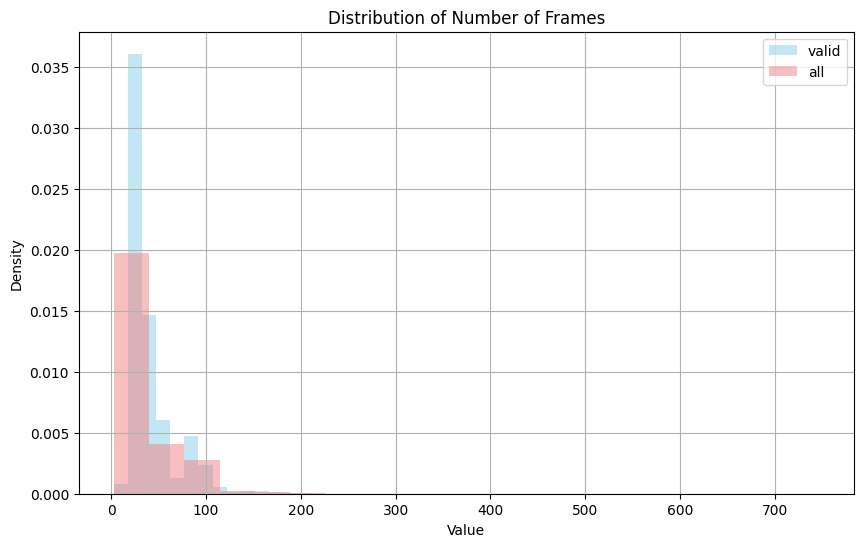

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(valid_metadata['n_frames'], bins=20, alpha=0.5, label='valid', color='skyblue', density=True)
plt.hist(metadata['n_frames'], bins=20, alpha=0.5, label='all', color='lightcoral', density=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Distribution of Number of Frames')
plt.legend()
plt.grid(True)
plt.show()

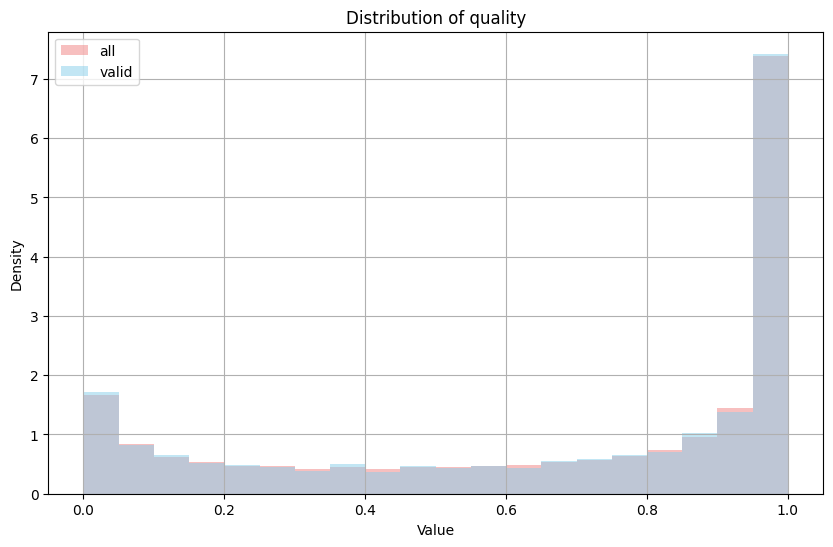

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(metadata['quality'], bins=20, alpha=0.5, label='all', color='lightcoral', density=True)
plt.hist(valid_metadata['quality'], bins=20, alpha=0.5, label='valid', color='skyblue', density=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Distribution of quality')
plt.legend()
plt.grid(True)
plt.show()

# Model


In [ ]:
from sklearn.model_selection import train_test_split
from PIL import Image # Import Image for readability check

# 1. Filter for valid paths and take a subset of 100 images
# We use `metadata[metadata['exists']]` to ensure we only use images that actually exist
valid_data = metadata[metadata['exists']].head(2000).copy() # Use .copy() to avoid SettingWithCopyWarning

# Add an additional filter for image readability
readable_indices = []
print("Verifying image readability...")
for idx, path in valid_data['png_path'].items(): # Use .items() for index and value
    try:
        with Image.open(path) as img: # Open in context manager to ensure file is closed
            img.verify() # Verify file integrity
        readable_indices.append(idx)
    except Exception as e:
        print(f"Skipping unreadable image: {path} due to error: {e}")

valid_data = valid_data.loc[readable_indices]
print(f"Found {len(valid_data)} readable images out of initial 100 (or fewer if some were unreadable).")

# 2. Define Inputs (X) and Labels (y)
X = valid_data['png_path']
y = valid_data['quality']

# 3. Perform the 80:20 split
# random_state ensures your results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 4. Verify the results
print(f"Total samples used for training and testing: {len(valid_data)}")
print(f"Training set size: {len(X_train)} images")
print(f"Testing set size: {len(X_test)} images")

Verifying image readability...
Skipping unreadable image: /content/drive/MyDrive/BME 499L: Senior Design iCardio/A4C iCardio/frames/8D/0B/di-8D0B-3437-CF4C_0.png due to error: cannot identify image file '/content/drive/MyDrive/BME 499L: Senior Design iCardio/A4C iCardio/frames/8D/0B/di-8D0B-3437-CF4C_0.png'
Found 1999 readable images out of initial 100 (or fewer if some were unreadable).
Total samples used for training and testing: 1999
Training set size: 1599 images
Testing set size: 400 images


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class EchoDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths.values
        self.labels = labels.values.astype('float32')
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # Load image and convert to RGB (standard for pre-trained models)
        image = Image.open(self.paths[idx]).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label)

# Define standard medical imaging transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize DataLoaders
train_ds = EchoDataset(X_train, y_train, transform=transform)
test_ds = EchoDataset(X_test, y_test, transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

In [ ]:
import torch.nn as nn
from torchvision import models

def get_regression_model():
    # Use ResNet18 as the backbone
    model = models.resnet18(weights='DEFAULT')

    # Change the final fully connected layer for regression
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 1),
        nn.Sigmoid() # Use Sigmoid if quality scores are strictly between 0 and 1
    )
    return model

model = get_regression_model()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 265MB/s]


In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Epoch [1/20] | Train Loss: 0.0955 | Val Loss: 0.0685
Epoch [2/20] | Train Loss: 0.0443 | Val Loss: 0.0731
Epoch [3/20] | Train Loss: 0.0228 | Val Loss: 0.0546
Epoch [4/20] | Train Loss: 0.0129 | Val Loss: 0.0545
Epoch [5/20] | Train Loss: 0.0106 | Val Loss: 0.0532
Epoch [6/20] | Train Loss: 0.0083 | Val Loss: 0.0547
Epoch [7/20] | Train Loss: 0.0075 | Val Loss: 0.0508
Epoch [8/20] | Train Loss: 0.0073 | Val Loss: 0.0503
Epoch [9/20] | Train Loss: 0.0068 | Val Loss: 0.0483
Epoch [10/20] | Train Loss: 0.0063 | Val Loss: 0.0542
Epoch [11/20] | Train Loss: 0.0058 | Val Loss: 0.0501
Epoch [12/20] | Train Loss: 0.0062 | Val Loss: 0.0564
Epoch [13/20] | Train Loss: 0.0069 | Val Loss: 0.0502
Epoch [14/20] | Train Loss: 0.0058 | Val Loss: 0.0520
Epoch [15/20] | Train Loss: 0.0040 | Val Loss: 0.0533
Epoch [16/20] | Train Loss: 0.0056 | Val Loss: 0.0503
Epoch [17/20] | Train Loss: 0.0046 | Val Loss: 0.0519
Epoch [18/20] | Train Loss: 0.0040 | Val Loss: 0.0497
Epoch [19/20] | Train Loss: 0.0033 | 

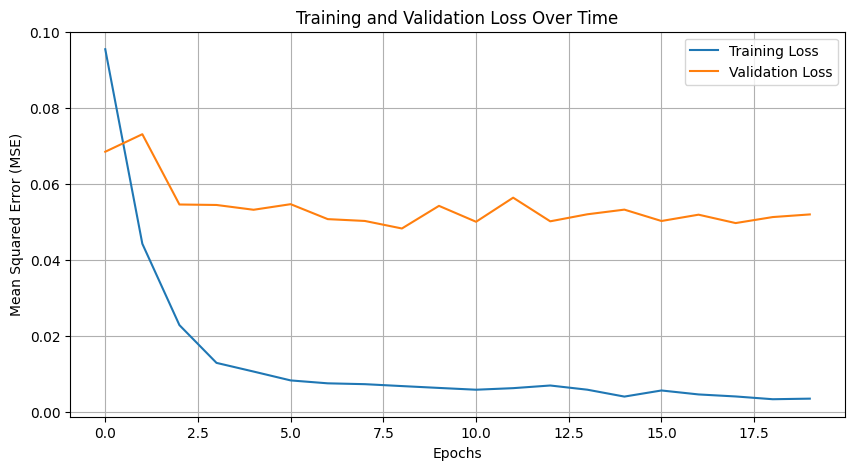

In [ ]:
import torch
import matplotlib.pyplot as plt

# 1. Initialize lists to store losses
train_losses = []
val_losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
num_epochs = 20

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0

    if epoch == num_epochs - 1:
        all_final_preds = []
        all_final_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

            # Store the raw continuous values
            if epoch == num_epochs - 1:
                all_final_preds.append(outputs.cpu())
                all_final_labels.append(labels.cpu())

    # 2. Save average losses for plotting
    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_val_loss = val_loss / len(test_loader.dataset)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# 3. Plotting the learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()


--- Final Evaluation (Threshold: 0.9) ---
AUC-ROC: 0.8990
AUC-PR:  0.8456


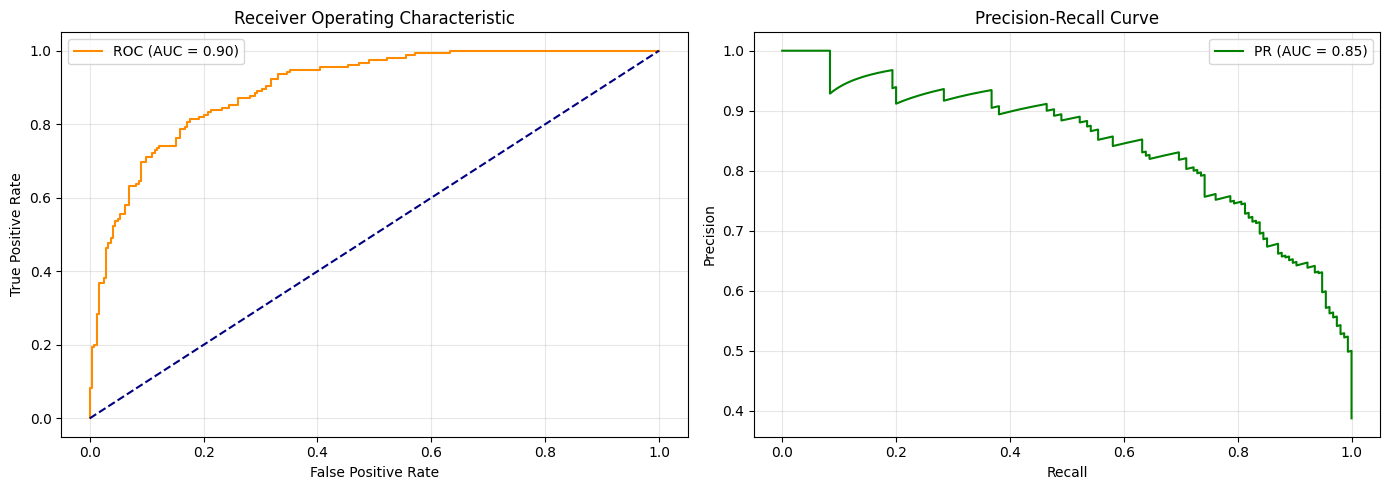

In [ ]:
# 4. AUC-ROC AND AUC-PR CALCULATION (AFTER TRAINING)
# ==========================================

import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

# Flatten the collected PyTorch tensors into 1D NumPy arrays
y_scores = torch.cat(all_final_preds).numpy().flatten()
y_true_cont = torch.cat(all_final_labels).numpy().flatten()

# Binarize the continuous labels based on a threshold
threshold = 0.9
y_true_binary = (y_true_cont > threshold).astype(int)

# Calculate Metrics
auc_roc = roc_auc_score(y_true_binary, y_scores)
auc_pr = average_precision_score(y_true_binary, y_scores)

print(f"\n--- Final Evaluation (Threshold: {threshold}) ---")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR:  {auc_pr:.4f}")

# 5. Plotting the AUC Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true_binary, y_scores)
ax1.plot(fpr, tpr, label=f'ROC (AUC = {auc_roc:.2f})', color='darkorange')
ax1.plot([0, 1], [0, 1], linestyle='--', color='navy')
ax1.set_title('Receiver Operating Characteristic')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PR Curve
precision, recall, _ = precision_recall_curve(y_true_binary, y_scores)
ax2.plot(recall, precision, label=f'PR (AUC = {auc_pr:.2f})', color='green')
ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import os

# Use the parent_dir you already defined in your notebook
save_path = os.path.join(parent_dir, 'quality_model_weights.pth')
torch.save(model.state_dict(), save_path)
print(f"Saved weights from the interrupted session to {save_path}")

Saved weights from the interrupted session to /content/drive/MyDrive/BME 499L: Senior Design iCardio/A4C iCardio/quality_model_weights.pth


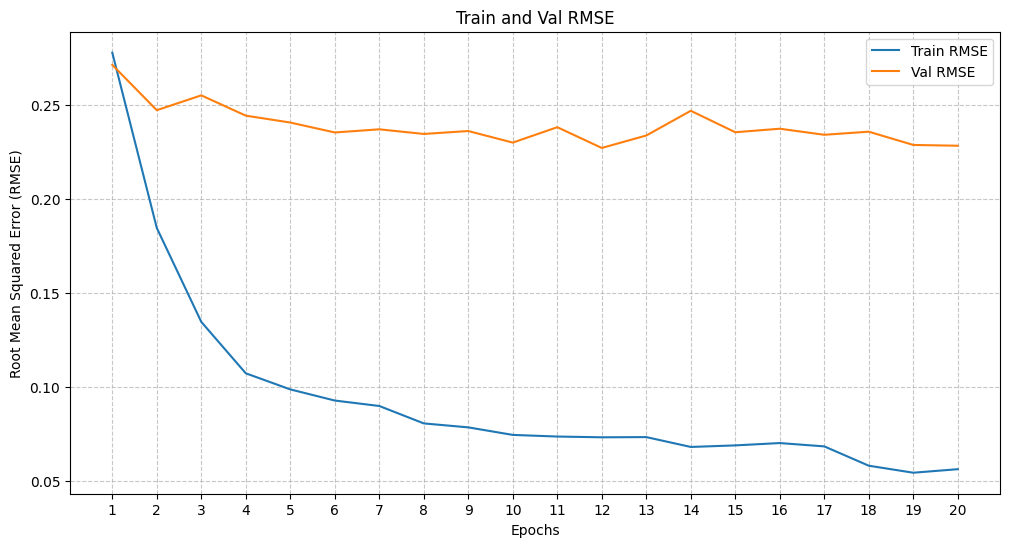

In [ ]:
# 1. Calculate RMSE by taking the square root of the stored MSE losses
train_rmse = [np.sqrt(l) for l in train_losses]
val_rmse = [np.sqrt(l) for l in val_losses]

# 2. Plotting the RMSE curves
plt.figure(figsize=(12, 6))
epochs = range(1, len(train_rmse) + 1) # Create range for x-axis starting at 1

plt.plot(epochs, train_rmse, label='Train RMSE')#, marker='o', markersize=4)
plt.plot(epochs, val_rmse, label='Val RMSE')#, marker='o', markersize=4)

# 3. Customize the x-axis to show every epoch
plt.xticks(np.arange(1, len(train_rmse) + 1, 1))

plt.xlabel('Epochs')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Train and Val RMSE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [ ]:
def get_quality_score(file_path, model, device='cuda'):
    """
    Loads a DICOM, preprocesses the first frame, and returns the quality score.
    """
    # 1. Load the DICOM file
    ds = pydicom.dcmread(file_path)
    pixel_array = ds.pixel_array

    # 2. Extract first frame if it's a video/multi-frame
    if len(pixel_array.shape) == 3:
        frame = pixel_array[0]
    else:
        frame = pixel_array

    # 3. Preprocessing (Adjust these to match your specific model's training)
    # Convert to PIL for easy resizing
    img = Image.fromarray(frame).convert('L') # 'L' for grayscale
    img = img.resize((224, 224)) # Example size, change to your model's input size

    # Convert to tensor and normalize
    img_tensor = torch.tensor(np.array(img)).float().unsqueeze(0).unsqueeze(0) # [Batch, Channel, H, W]
    img_tensor = img_tensor / 255.0  # Simple 0-1 normalization

    # 4. Inference
    model.eval()
    with torch.no_grad():
        img_tensor = img_tensor.to(device)
        output = model(img_tensor)

        # If your model output is a single scalar (regression)
        score = output.item()

    return score